In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.preprocessing import TransactionEncoder

In [2]:
# Section 1: Data Collection
transactions_df = pd.read_csv('Groceries_dataset.csv')
transactions_df.head()

,Member_number,Date,itemDescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [3]:
print(f"Rows: {transactions_df.shape[0]}")
print(f"Columns: {transactions_df.shape[1]}")

Rows: 38765
Columns: 7


In [4]:
# Section 2: Data Preprocessing
transactions_df.columns = transactions_df.columns.str.lower().str.strip()
print("Columns:")
list(transactions_df.columns)

Columns:


['member_number',
 'date',
 'itemdescription',
 'year',
 'month',
 'day',
 'day_of_week']

In [5]:
transactions_df.drop_duplicates(inplace=True)
transactions_df.reset_index(drop=True, inplace= True)
print("Removed Duplicates:")
transactions_df.head()

Removed Duplicates:


,member_number,date,itemdescription,year,month,day,day_of_week
0,1808,2015-07-21,tropical fruit,2015,7,21,1
1,2552,2015-05-01,whole milk,2015,5,1,4
2,2300,2015-09-19,pip fruit,2015,9,19,5
3,1187,2015-12-12,other vegetables,2015,12,12,5
4,3037,2015-01-02,whole milk,2015,1,2,4


In [6]:
grouped = transactions_df.groupby('member_number')['itemdescription']
grouped_list = grouped.agg(list).reset_index()
print("Grouped Transactions:")
grouped_list.head()

Grouped Transactions:


,member_number,itemdescription
0,1000,"[soda, canned beer, sausage, sausage, whole mi..."
1,1001,"[frankfurter, frankfurter, beef, sausage, whol..."
2,1002,"[tropical fruit, butter milk, butter, frozen v..."
3,1003,"[sausage, root vegetables, rolls/buns, deterge..."
4,1004,"[other vegetables, pip fruit, root vegetables,..."


In [7]:
transactions_list = grouped_list['itemdescription'].tolist()
print(f"Total transactions prepared: {len(transactions_list)}")
transactions_list[:5]

Total transactions prepared: 3898


[['soda',
  'canned beer',
  'sausage',
  'sausage',
  'whole milk',
  'whole milk',
  'pickled vegetables',
  'misc. beverages',
  'semi-finished bread',
  'hygiene articles',
  'yogurt',
  'pastry',
  'salty snack'],
 ['frankfurter',
  'frankfurter',
  'beef',
  'sausage',
  'whole milk',
  'soda',
  'curd',
  'white bread',
  'whole milk',
  'soda',
  'whipped/sour cream',
  'rolls/buns'],
 ['tropical fruit',
  'butter milk',
  'butter',
  'frozen vegetables',
  'sugar',
  'specialty chocolate',
  'whole milk',
  'other vegetables'],
 ['sausage',
  'root vegetables',
  'rolls/buns',
  'detergent',
  'frozen meals',
  'rolls/buns',
  'dental care'],
 ['other vegetables',
  'pip fruit',
  'root vegetables',
  'canned beer',
  'rolls/buns',
  'whole milk',
  'other vegetables',
  'hygiene articles',
  'whole milk',
  'whole milk',
  'frozen fish',
  'red/blush wine',
  'chocolate',
  'shopping bags',
  'dish cleaner',
  'packaged fruit/vegetables',
  'tropical fruit',
  'rolls/buns',
 

In [8]:
te = TransactionEncoder()
te_array = te.fit(transactions_list).transform(transactions_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [9]:
# Section 3: Apriori
min_support = 0.003
min_confidence = 0.5
min_lift = 3
min_length = 1
max_length = 4

try:
    df_encoded
except NameError:
    raise NameError("df_encoded not found. Run the one-hot encoding block (Section 2b) first.")

frequent_itemsets = mlxtend_apriori(df_encoded, min_support=min_support, use_colnames=True)

frequent_itemsets['itemset_len'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

frequent_itemsets = frequent_itemsets[
    (frequent_itemsets['itemset_len'] >= min_length) &
    (frequent_itemsets['itemset_len'] <= max_length)
].reset_index(drop=True)

if frequent_itemsets.empty:
    print("No frequent itemsets found for min_support =", min_support)
    rules_df = pd.DataFrame(columns=["antecedents","consequents","support","confidence","lift"])
else:
    rules_df = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    rules_df['antecedent_len'] = rules_df['antecedents'].apply(lambda x: len(x))
    rules_df['consequent_len'] = rules_df['consequents'].apply(lambda x: len(x))
    rules_df = rules_df[
        (rules_df['lift'] >= min_lift) &
        (rules_df['antecedent_len'] >= min_length) &
        (rules_df['antecedent_len'] <= max_length)
    ].reset_index(drop=True)

def inspect_mlxtend(rules):
    if rules.empty:
        return []
    lhs = rules["antecedents"].apply(lambda x: tuple(sorted(x))).tolist()
    rhs = rules["consequents"].apply(lambda x: tuple(sorted(x))).tolist()
    support = rules["support"].tolist()
    confidence = rules["confidence"].tolist()
    lift = rules["lift"].tolist()
    return list(zip(lhs, rhs, support, confidence, lift))

result_df = pd.DataFrame(inspect_mlxtend(rules_df),
                         columns=["left_hand_side", "right_hand_side", "support", "confidence", "lift"])
result_df = result_df.sort_values(by="lift", ascending=False).reset_index(drop=True)

display(result_df)

,left_hand_side,right_hand_side,support,confidence,lift
0,"(sliced cheese, waffles)","(whole milk, yogurt)",0.003079,0.800000,5.312436
1,"(hamburger meat, waffles)","(other vegetables, soda)",0.003335,0.541667,4.362431
2,"(brown bread, domestic eggs, root vegetables)","(pastry,)",0.003335,0.684211,3.854122
3,"(other vegetables, pip fruit, waffles)","(pork,)",0.003079,0.500000,3.777132
4,"(dessert, red/blush wine)","(pastry,)",0.003592,0.666667,3.755299
5,"(beef, sliced cheese)","(whole milk, yogurt)",0.003335,0.565217,3.753352
6,"(cat food, sugar)","(other vegetables, whole milk)",0.003079,0.705882,3.688377
7,"(condensed milk, whipped/sour cream)","(sausage,)",0.003079,0.750000,3.640722
8,"(newspapers, sugar, yogurt)","(sausage,)",0.003079,0.750000,3.640722
9,"(citrus fruit, grapes, other vegetables)","(frankfurter,)",0.003079,0.500000,3.636194


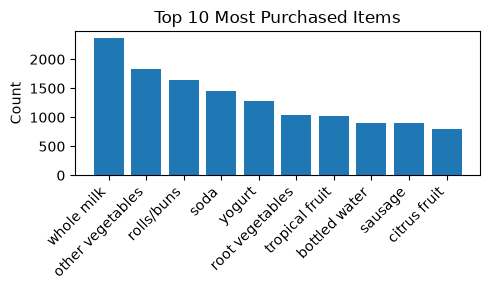

In [10]:
# Section 4: Bar chart - Top 10 Most Purchased Items
import matplotlib.pyplot as plt
from collections import Counter

all_items = [item for tx in transactions_list for item in tx]
item_counts = Counter(all_items)
top10 = item_counts.most_common(10)
top10_df = pd.DataFrame(top10, columns=['item','count'])

plt.figure(figsize=(5,3))
plt.bar(top10_df['item'], top10_df['count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Top 10 Most Purchased Items')
plt.tight_layout()
plt.show()

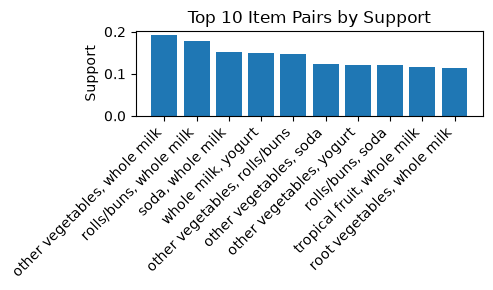

In [11]:
# Section 5: Bar chart - Top 10 Item Combinations (pairs) by support
from itertools import combinations

pair_counts = Counter()
for tx in transactions_list:
    unique_items = sorted(set(tx))
    for a,b in combinations(unique_items, 2):
        pair_counts[(a,b)] += 1

n_tx = len(transactions_list)
pairs_df = pd.DataFrame([
    {'itemA': a, 'itemB': b, 'count': cnt, 'support': cnt / n_tx}
    for (a,b), cnt in pair_counts.items()
])
pairs_df = pairs_df.sort_values('support', ascending=False).reset_index(drop=True)
top10_pairs = pairs_df.head(10).copy()
top10_pairs['pair_str'] = top10_pairs['itemA'] + ', ' + top10_pairs['itemB']

plt.figure(figsize=(5,3))
plt.bar(top10_pairs['pair_str'], top10_pairs['support'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Support')
plt.title('Top 10 Item Pairs by Support')
plt.tight_layout()
plt.show()


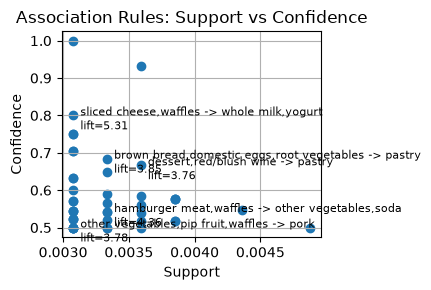

In [12]:
# Section 6: Scatter plot - Support vs Confidence for rules found by apyori

if 'result_df' not in globals():
    raise RuntimeError("result_df not found. Run Section 3 (Apriori) first.")

plt.figure(figsize=(4,3))
plt.scatter(result_df['support'], result_df['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.grid(True)

try:
    top5 = result_df.sort_values('lift', ascending=False).head(5)
    for _, row in top5.iterrows():
        lhs = ','.join(row['left_hand_side']) if isinstance(row['left_hand_side'], (list, tuple)) else str(row['left_hand_side'])
        rhs = ','.join(row['right_hand_side']) if isinstance(row['right_hand_side'], (list, tuple)) else str(row['right_hand_side'])
        label = f"{lhs} -> {rhs}\nlift={row['lift']:.2f}"
        plt.annotate(label, (row['support'], row['confidence']), textcoords="offset points", xytext=(5,-10), fontsize=8)
except Exception as e:
    print("Annotate skipped:", e)

plt.tight_layout()
plt.show()

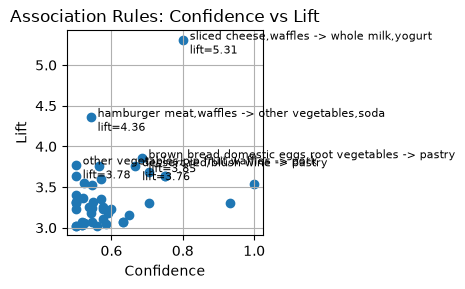

In [13]:
# Section 7: Scatter plot - Confidence vs Lift for rules found by apyori
import matplotlib.pyplot as plt

if 'result_df' not in globals():
    raise RuntimeError("rResult_df not found. Run Section 3 (Apriori) first.")

plt.figure(figsize=(4,3))
plt.scatter(result_df['confidence'], result_df['lift'])
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs Lift')
plt.grid(True)

try:
    top5_lift = result_df.sort_values('lift', ascending=False).head(5)
    for _, row in top5_lift.iterrows():
        lhs = ','.join(row['left_hand_side']) if isinstance(row['left_hand_side'], (list, tuple)) else str(row['left_hand_side'])
        rhs = ','.join(row['right_hand_side']) if isinstance(row['right_hand_side'], (list, tuple)) else str(row['right_hand_side'])
        label = f"{lhs} -> {rhs}\nlift={row['lift']:.2f}"
        plt.annotate(label, (row['confidence'], row['lift']), textcoords="offset points", xytext=(5,-10), fontsize=8)
except Exception as e:
    print("Annotate skipped:", e)

plt.tight_layout()
plt.show()

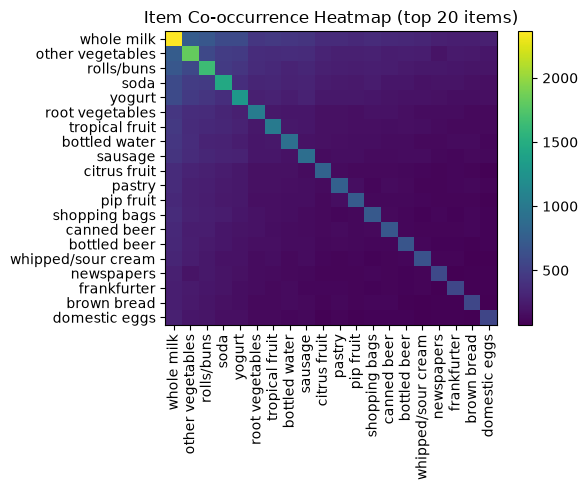

In [14]:
# Section 7: Heatmap - Item Co-occurrence (top N items)
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

if 'transactions_list' not in globals():
    raise RuntimeError("transactions_list not found. Run Section 2 (preprocessing) first.")

TOP_N = 20
all_items = [item for tx in transactions_list for item in tx]
item_counts = Counter(all_items)
top_items = [it for it,_ in item_counts.most_common(TOP_N)]

idx = {it:i for i,it in enumerate(top_items)}
mat = np.zeros((len(top_items), len(top_items)), dtype=int)

for tx in transactions_list:
    items = set(tx) & set(top_items)
    for a,b in combinations(items, 2):
        i,j = idx[a], idx[b]
        mat[i,j] += 1
        mat[j,i] += 1

for it,i in idx.items():
    mat[i,i] = item_counts[it]

plt.figure(figsize=(6,5))
plt.imshow(mat, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(ticks=np.arange(len(top_items)), labels=top_items, rotation=90)
plt.yticks(ticks=np.arange(len(top_items)), labels=top_items)
plt.title(f'Item Co-occurrence Heatmap (top {len(top_items)} items)')
plt.tight_layout()
plt.show()